In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [36]:
# Load built-in datasets for practice
df = sns.load_dataset('tips')      # restaurant tips
df = sns.load_dataset('titanic')   # titanic passengers
df = sns.load_dataset('iris')      # iris flowers
df = sns.load_dataset('penguins')  # penguin measurements
df = sns.load_dataset('flights')   # monthly flight data

# List all available datasets
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


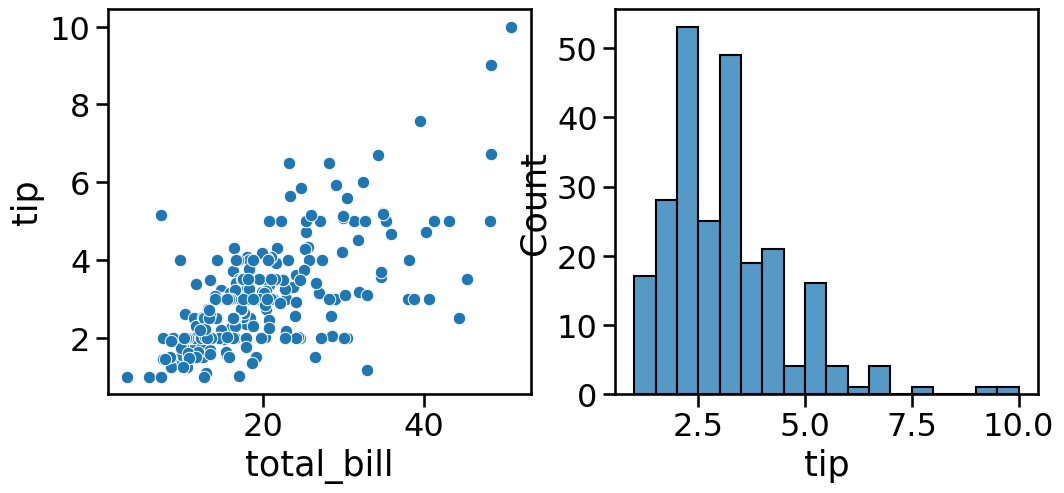

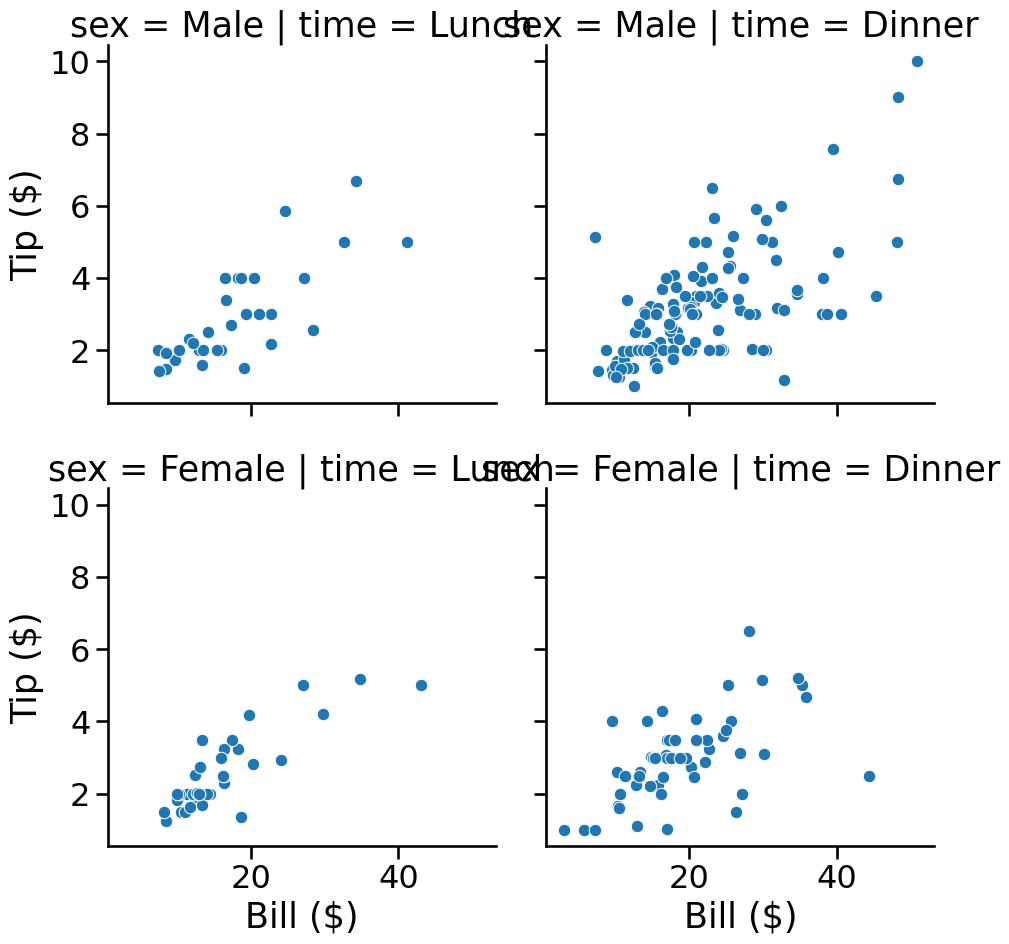

In [37]:
df = sns.load_dataset('tips')
# AXES-LEVEL: draws on one Axes, works with plt.subplots()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', ax=axes[0])
sns.histplot(data=df, x='tip', ax=axes[1])
plt.show()

# FIGURE-LEVEL: manages its own figure + subplots
g = sns.relplot(data=df, x='total_bill', y='tip',
                col='time', row='sex')
g.set_axis_labels('Bill ($)', 'Tip ($)')
plt.show()

# Figure-level functions: relplot, displot, catplot, lmplot
# Axes-level:  scatterplot, histplot, boxplot, regplot, ...

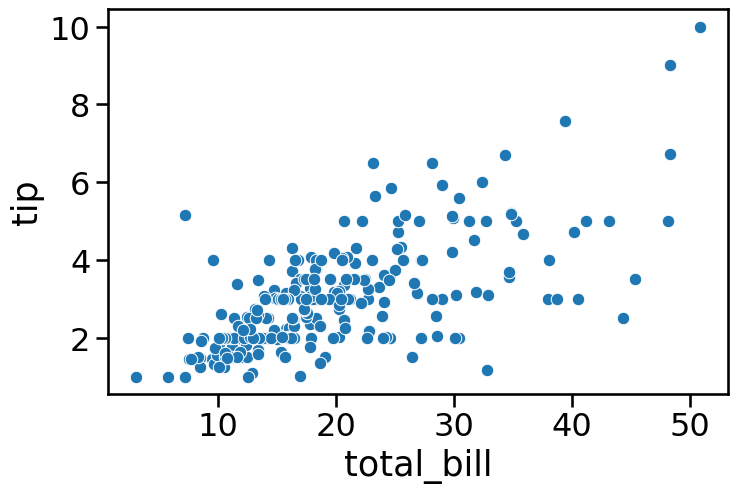

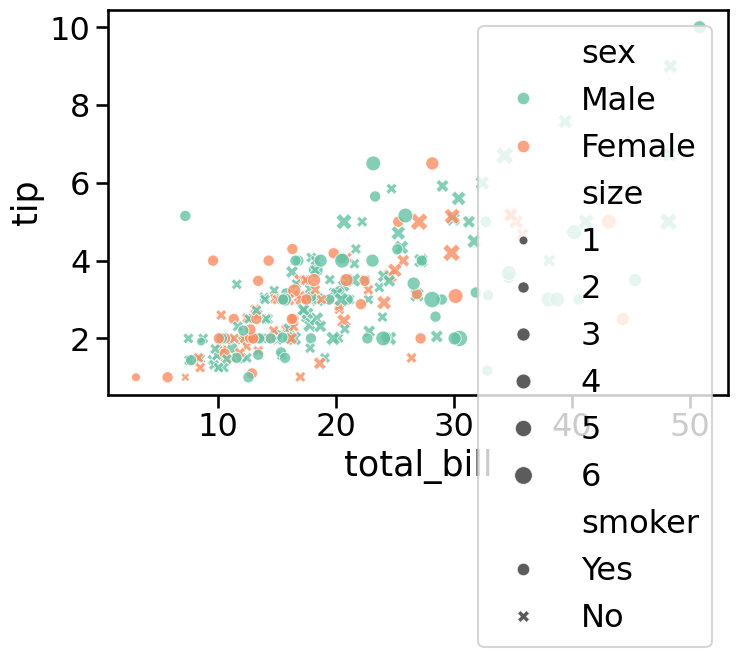

In [38]:
df = sns.load_dataset('tips')

# Basic scatter
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', ax=ax)
plt.show()

# With hue, size, style — encode 3 extra dimensions
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='total_bill', y='tip',
    hue='sex',       # color by category
    size='size',      # point size by value
    style='smoker',   # marker shape by category
    palette='Set2',
    alpha=0.8
)
plt.show()

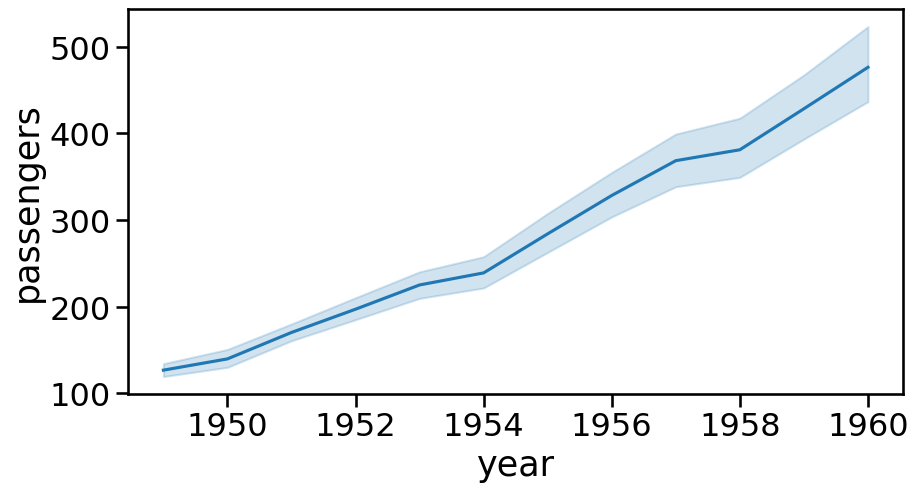

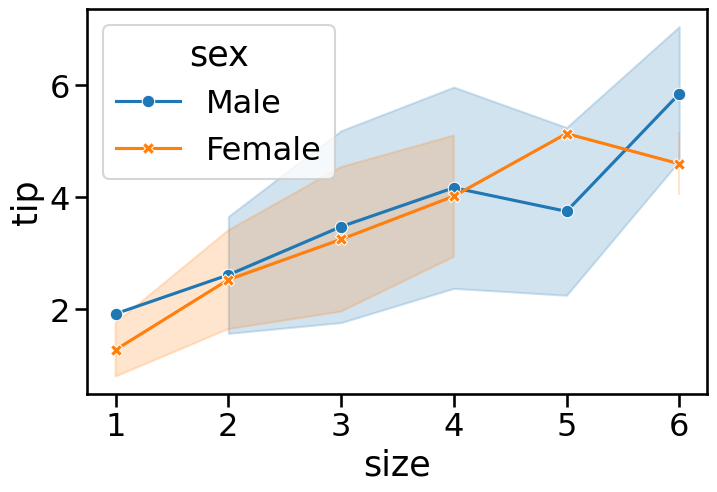

In [39]:
df = sns.load_dataset('flights')

# Basic line plot with auto CI
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df, x='year', y='passengers', ax=ax)
plt.show()

# Multiple lines with hue
df2 = sns.load_dataset('tips')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(
    data=df2, x='size', y='tip',
    hue='sex',
    style='sex',       # also vary line style
    markers=True,
    dashes=False,
    errorbar='sd',    # std dev instead of CI
    ax=ax
)
plt.show()

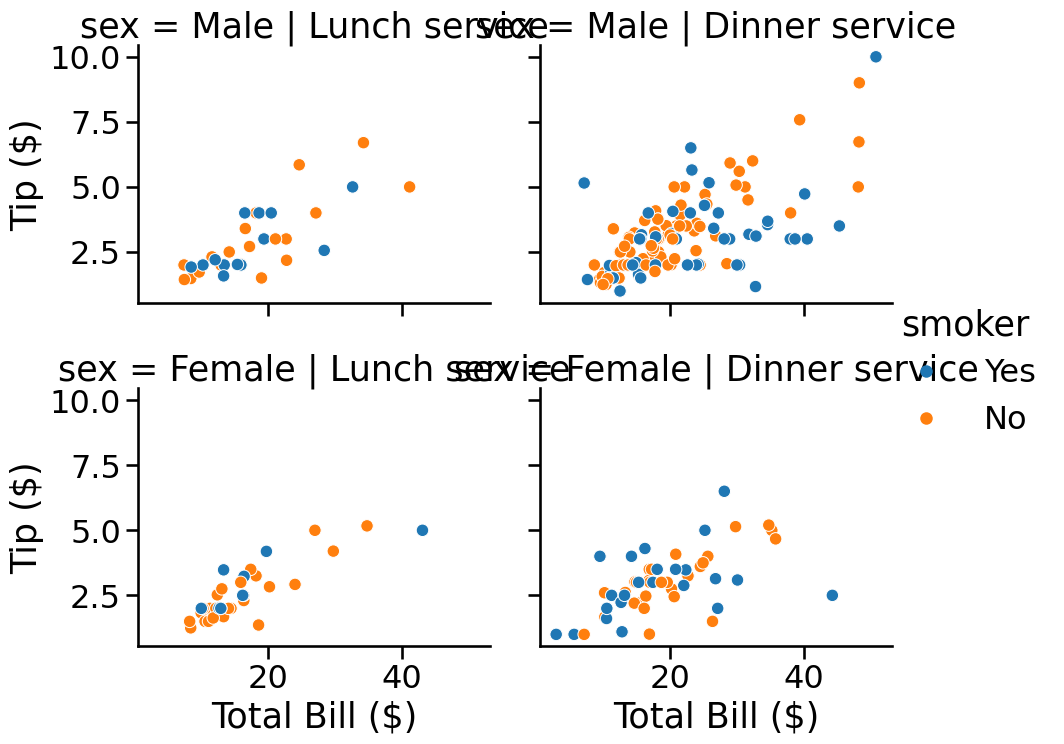

In [40]:
df = sns.load_dataset('tips')

# Grid of scatter plots split by col and row
g = sns.relplot(
    data=df,
    x='total_bill', y='tip',
    hue='smoker',
    col='time',       # one column per unique value
    row='sex',        # one row per unique value
    kind='scatter',   # or 'line'
    height=4,
    aspect=1.2
)
g.set_axis_labels('Total Bill ($)', 'Tip ($)')
g.set_titles(col_template='{col_name} service')
plt.show()

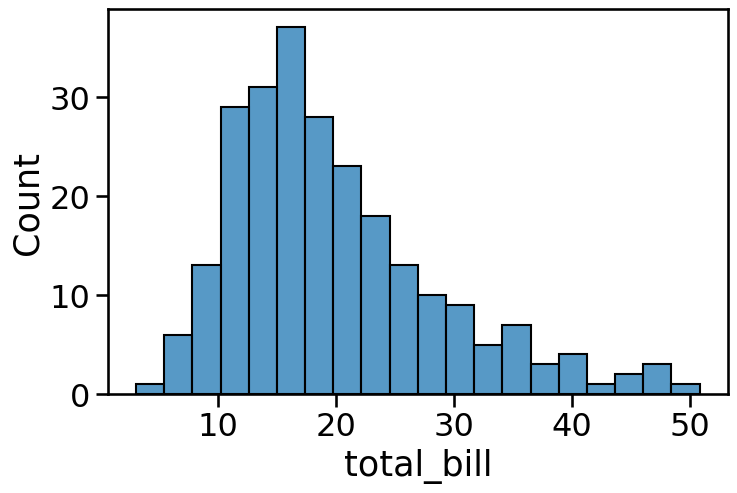

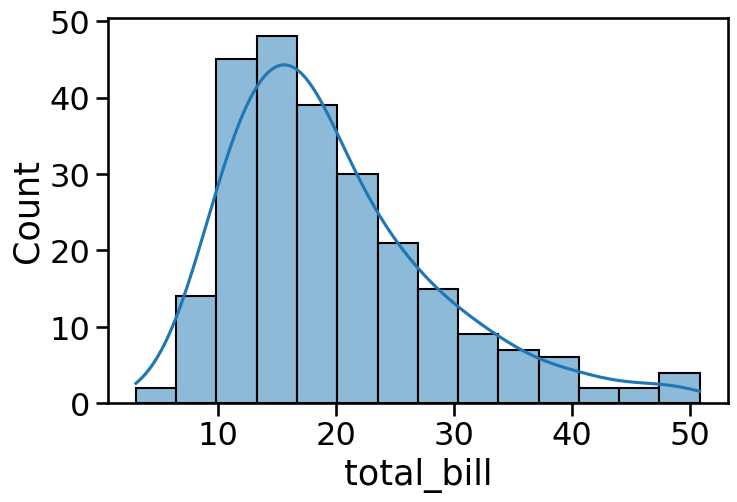

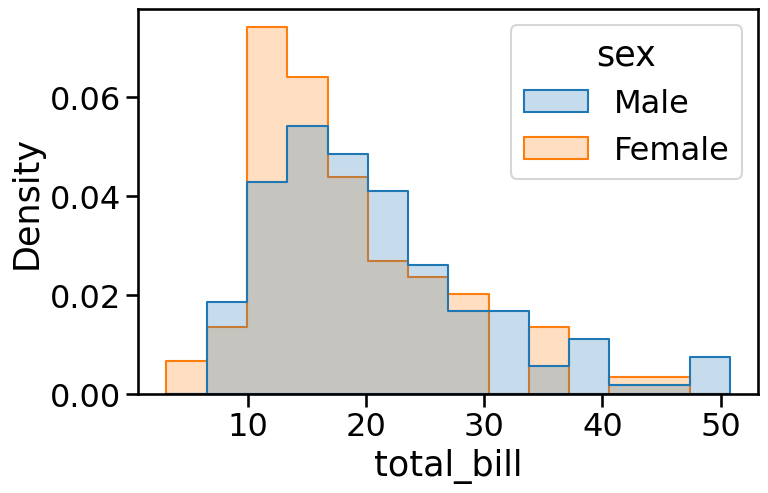

In [41]:
df = sns.load_dataset('tips')

# Basic histogram
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='total_bill', bins=20, ax=ax)
plt.show()

# With KDE curve
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='total_bill', kde=True, ax=ax)
plt.show()

# Overlapping histograms by category
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df, x='total_bill',
    hue='sex',
    element='step',      # 'bars' | 'step' | 'poly'
    stat='density',      # 'count' | 'density' | 'probability'
    common_norm=False,
    ax=ax
)
plt.show()

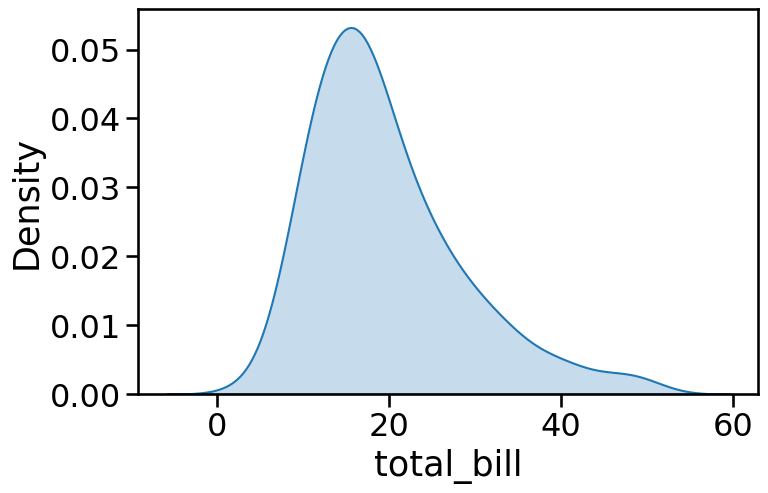

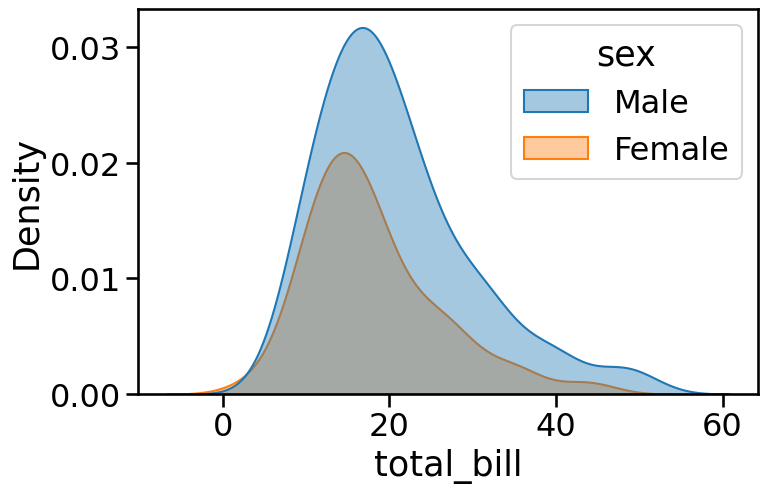

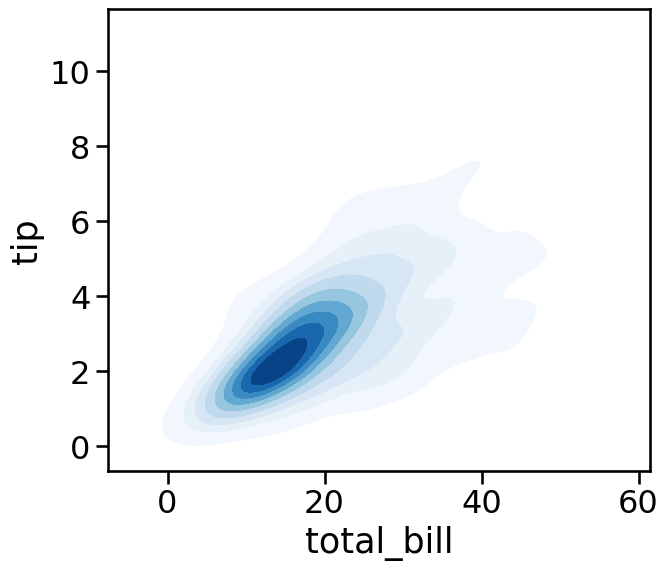

In [42]:
df = sns.load_dataset('tips')

# 1D KDE
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x='total_bill', fill=True, ax=ax)
plt.show()

# Multiple KDEs by hue
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x='total_bill', hue='sex',
            fill=True, alpha=0.4, ax=ax)
plt.show()

# 2D joint KDE (density contour)
fig, ax = plt.subplots(figsize=(7, 6))
sns.kdeplot(data=df, x='total_bill', y='tip',
            fill=True, cmap='Blues', thresh=0.05, ax=ax)
plt.show()

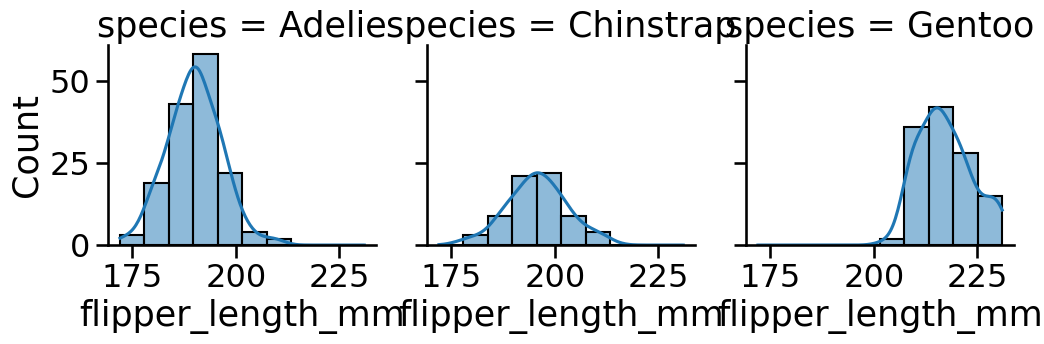

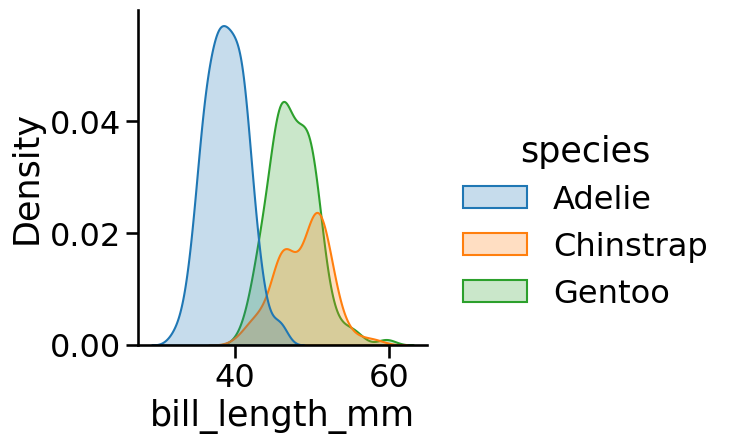

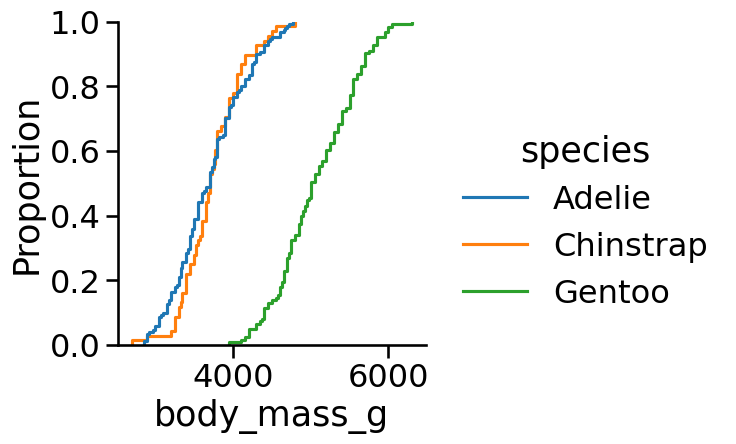

In [43]:
df = sns.load_dataset('penguins')

# Faceted histogram
sns.displot(data=df, x='flipper_length_mm',
            col='species', kde=True,
            height=4, aspect=0.9)
plt.show()

# KDE mode
sns.displot(data=df, x='bill_length_mm',
            hue='species', kind='kde',
            fill=True, height=5)
plt.show()

# ECDF (empirical cumulative distribution)
sns.displot(data=df, x='body_mass_g',
            hue='species', kind='ecdf')
plt.show()

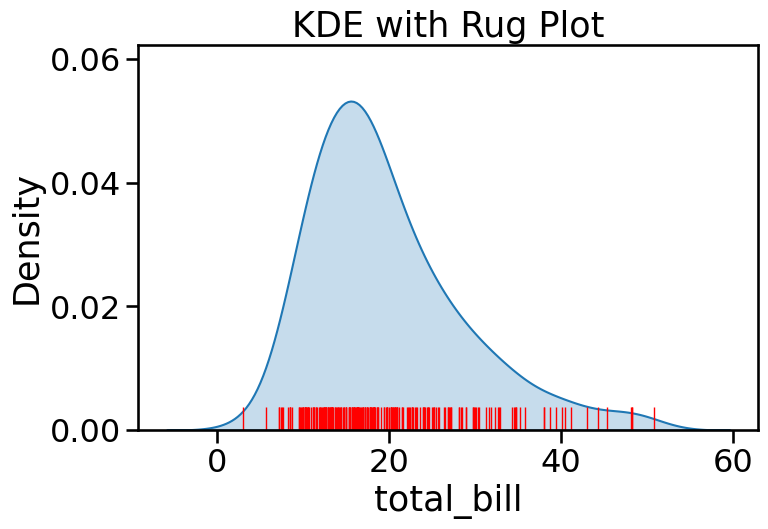

In [44]:
df = sns.load_dataset('tips')

fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x='total_bill', fill=True, ax=ax)
sns.rugplot(data=df, x='total_bill',
            color='red', height=0.06, ax=ax)
ax.set_title('KDE with Rug Plot')
plt.show()

C:\Users\vivek\AppData\Local\Temp\ipykernel_181876\4154738368.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day', y='tip',


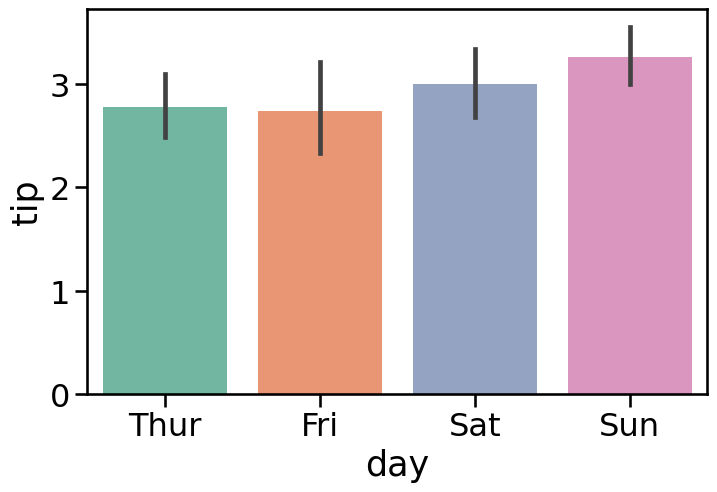

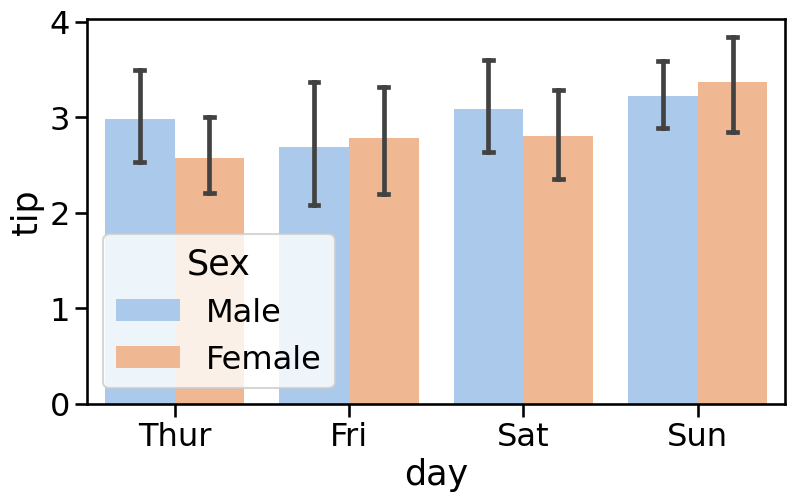

In [45]:
df = sns.load_dataset('tips')

# Mean tip per day
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='day', y='tip',
            palette='Set2', ax=ax)
plt.show()

# Grouped by hue
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x='day', y='tip',
            hue='sex', palette='pastel',
            errorbar='ci',       # confidence interval bars
            capsize=0.1, ax=ax)
ax.legend(title='Sex')
plt.show()

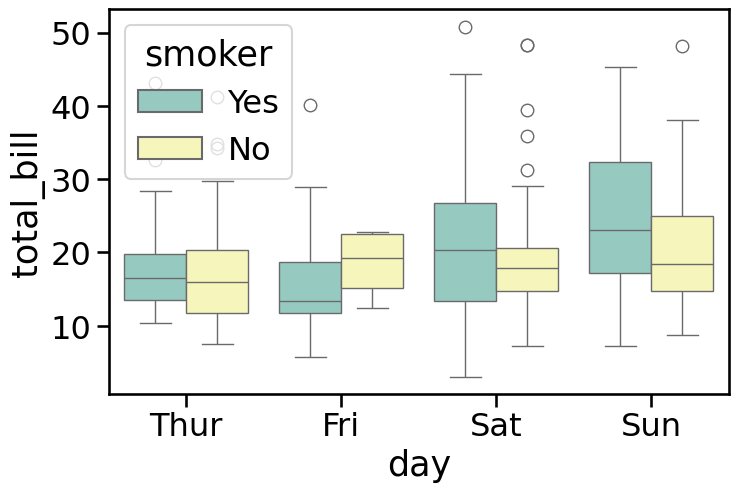

C:\Users\vivek\AppData\Local\Temp\ipykernel_181876\2867866625.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='day', y='total_bill',


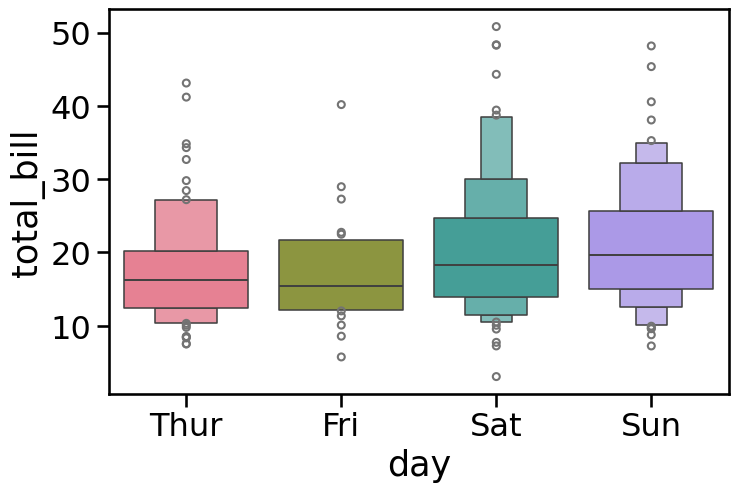

In [46]:
df = sns.load_dataset('tips')

# Standard box plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='day', y='total_bill',
            hue='smoker', palette='Set3', ax=ax)
plt.show()

# Boxen plot — shows more quantiles (better for large data)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxenplot(data=df, x='day', y='total_bill',
              palette='husl', ax=ax)
plt.show()

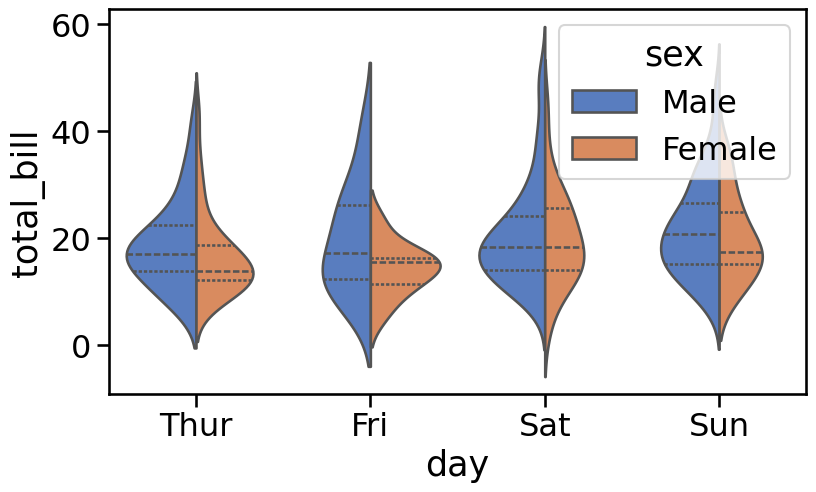

In [47]:
df = sns.load_dataset('tips')

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=df, x='day', y='total_bill',
    hue='sex',
    split=True,        # mirror halves for 2-category hue
    inner='quart',    # 'box' | 'quart' | 'point' | 'stick' | None
    palette='muted',
    ax=ax
)
plt.show()

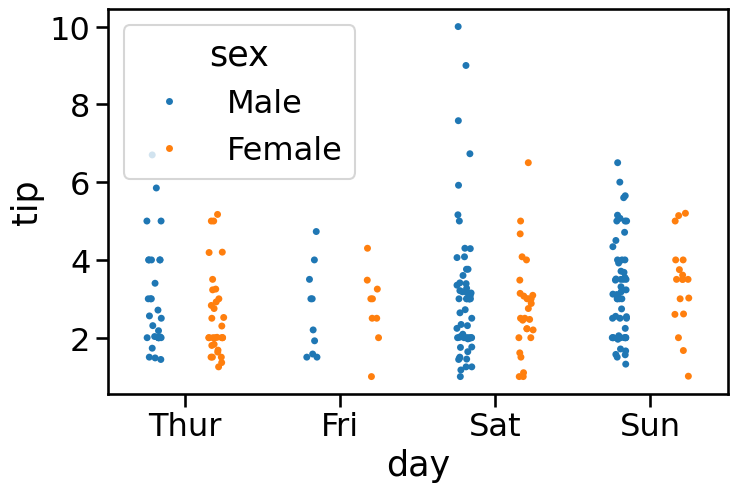

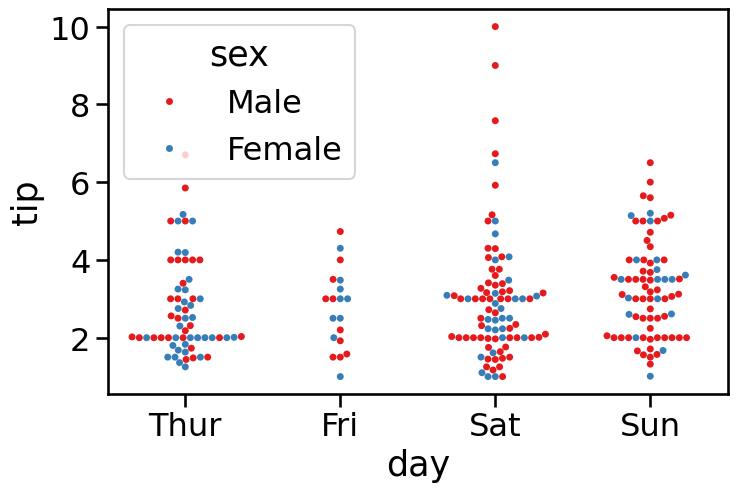

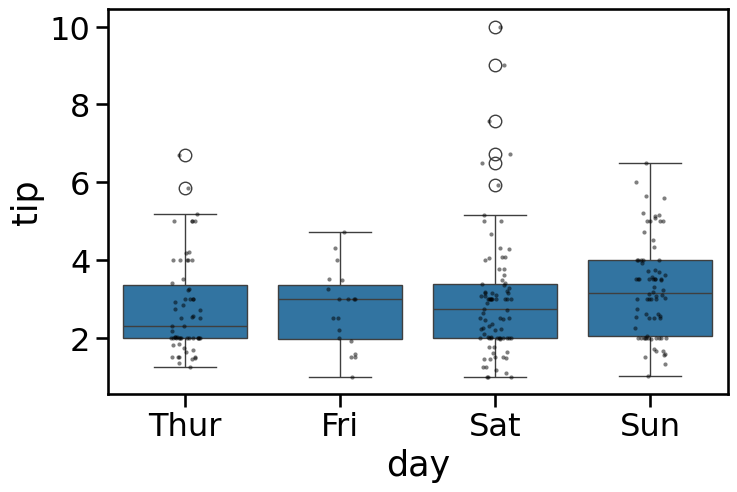

In [48]:
df = sns.load_dataset('tips')

# Strip plot — jittered points
fig, ax = plt.subplots(figsize=(8, 5))
sns.stripplot(data=df, x='day', y='tip',
              hue='sex', jitter=True, dodge=True, ax=ax)
plt.show()

# Swarm plot — non-overlapping points (slow on large data)
fig, ax = plt.subplots(figsize=(8, 5))
sns.swarmplot(data=df, x='day', y='tip',
              hue='sex', palette='Set1', ax=ax)
plt.show()

# Overlay strip on box for best of both
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='day', y='tip', ax=ax)
sns.stripplot(data=df, x='day', y='tip',
              color='black', size=3, alpha=0.5, ax=ax)
plt.show()

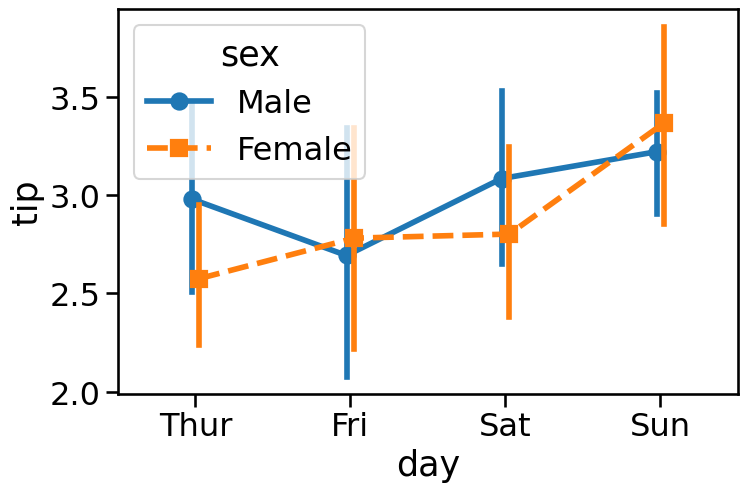

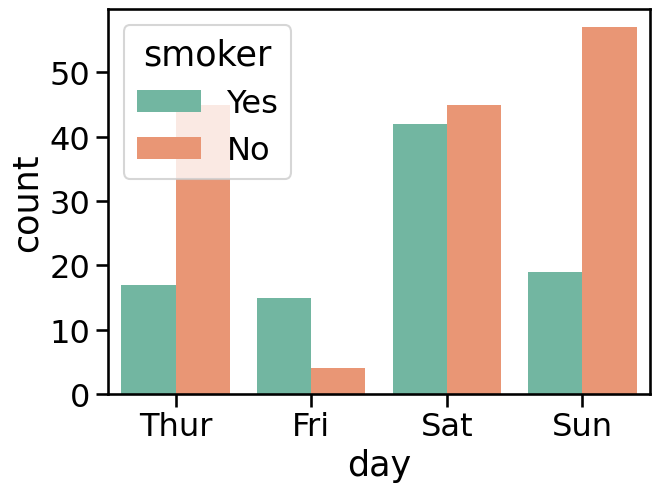

In [49]:
df = sns.load_dataset('tips')

# Point plot — means connected by lines
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(data=df, x='day', y='tip',
              hue='sex', dodge=True,
              markers=['o', 's'], linestyles=['-', '--'],
              ax=ax)
plt.show()

# Count plot — frequency of each category
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='day', hue='smoker',
              palette='Set2', ax=ax)
plt.show()

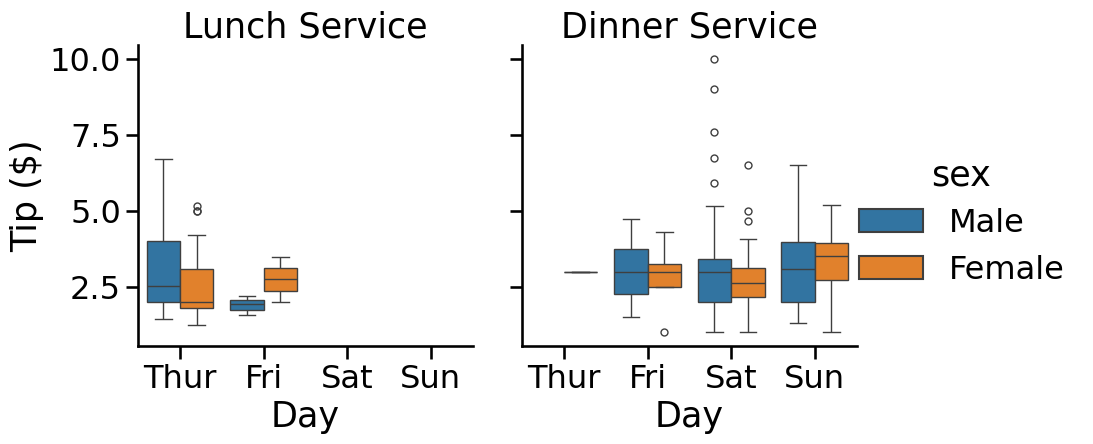

In [50]:
df = sns.load_dataset('tips')

# Faceted box plots
g = sns.catplot(
    data=df, x='day', y='tip',
    hue='sex', col='time',
    kind='box',    # 'strip' | 'swarm' | 'box' | 'violin' |
                    #  'boxen' | 'point' | 'bar' | 'count'
    height=5, aspect=0.9
)
g.set_axis_labels('Day', 'Tip ($)')
g.set_titles('{col_name} Service')
plt.show()

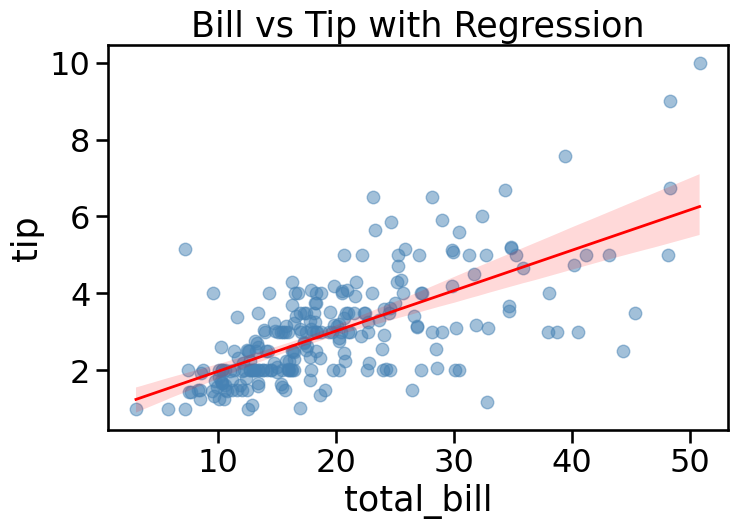

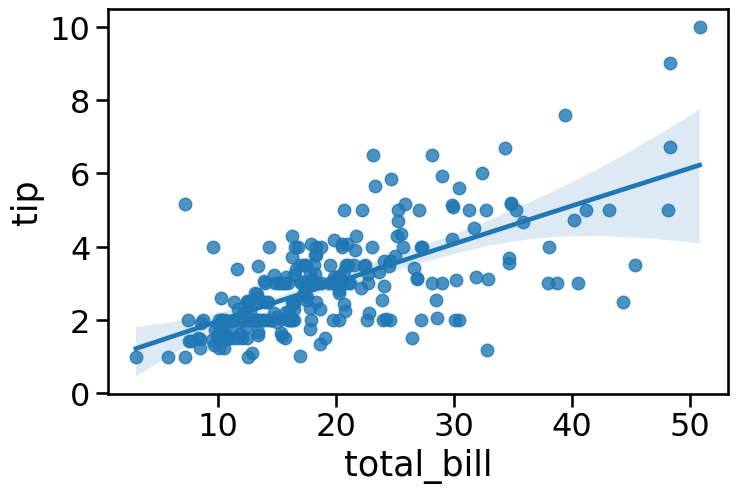

In [51]:
df = sns.load_dataset('tips')

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df, x='total_bill', y='tip',
    scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)
ax.set_title('Bill vs Tip with Regression')
plt.show()

# Polynomial regression
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='total_bill', y='tip',
            order=2, ax=ax)  # degree-2 polynomial
plt.show()

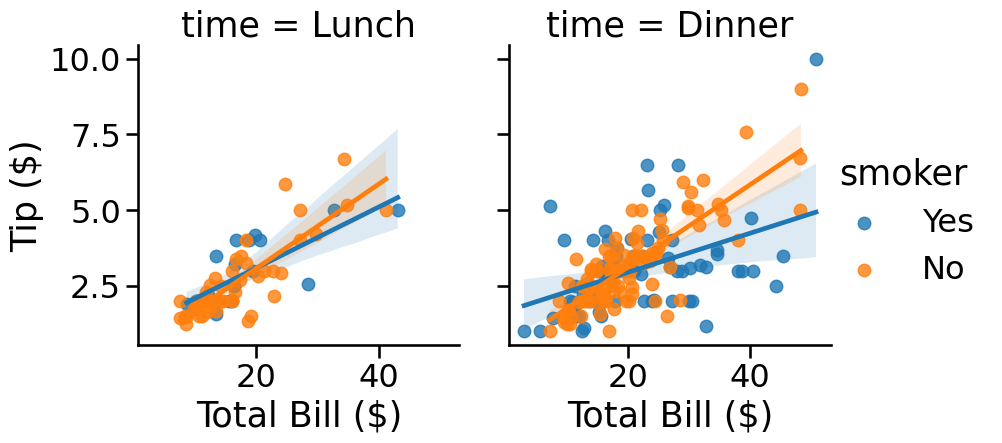

In [52]:
df = sns.load_dataset('tips')

# Regression per group with faceting
g = sns.lmplot(
    data=df,
    x='total_bill', y='tip',
    hue='smoker',      # separate regression per group
    col='time',        # one column per time
    height=5, aspect=0.9
)
g.set_axis_labels('Total Bill ($)', 'Tip ($)')
plt.show()

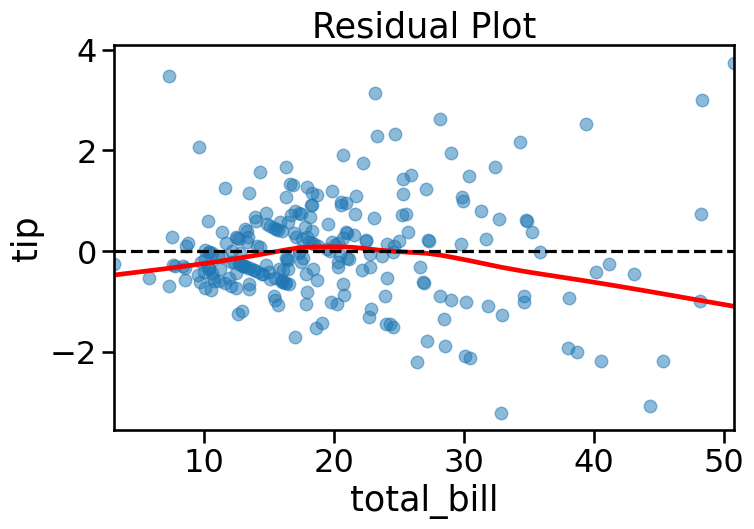

In [53]:
df = sns.load_dataset('tips')

fig, ax = plt.subplots(figsize=(8, 5))
sns.residplot(
    data=df, x='total_bill', y='tip',
    lowess=True,       # add a LOWESS smoothed line
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
    ax=ax
)
ax.axhline(0, color='black', linestyle='--')
ax.set_title('Residual Plot')
plt.show()

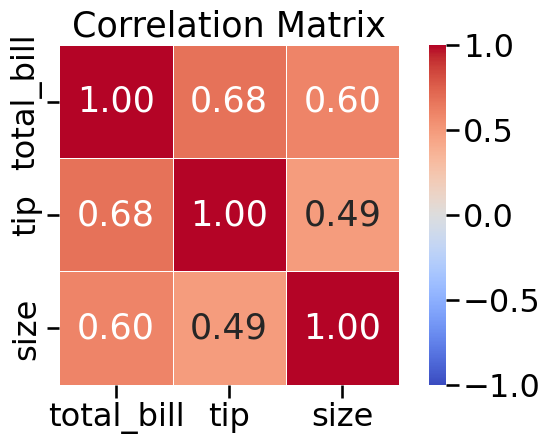

In [54]:
df = sns.load_dataset('tips')

# Correlation heatmap
corr = df.select_dtypes('number').corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,         # show values in cells
    fmt='.2f',           # number format
    cmap='coolwarm',    # diverging colormap
    vmin=-1, vmax=1,    # fix scale
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

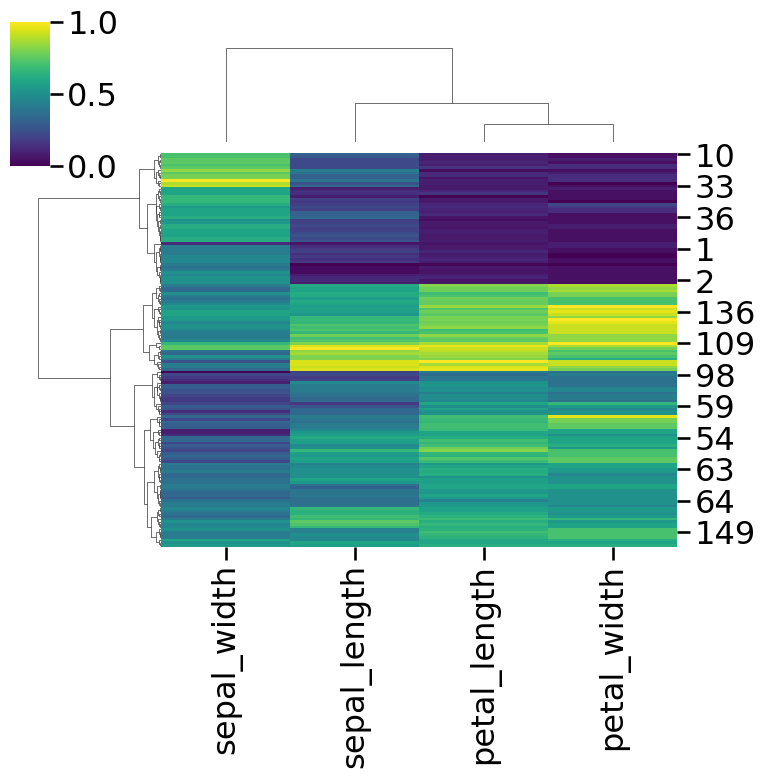

In [55]:
df = sns.load_dataset('iris').drop(columns=['species'])

# Cluster rows & columns, auto-reorder
g = sns.clustermap(
    df,
    method='ward',         # linkage method
    metric='euclidean',    # distance metric
    cmap='viridis',
    standard_scale=1,      # 0=rows, 1=columns z-score
    figsize=(8, 8),
    annot=False
)
plt.show()

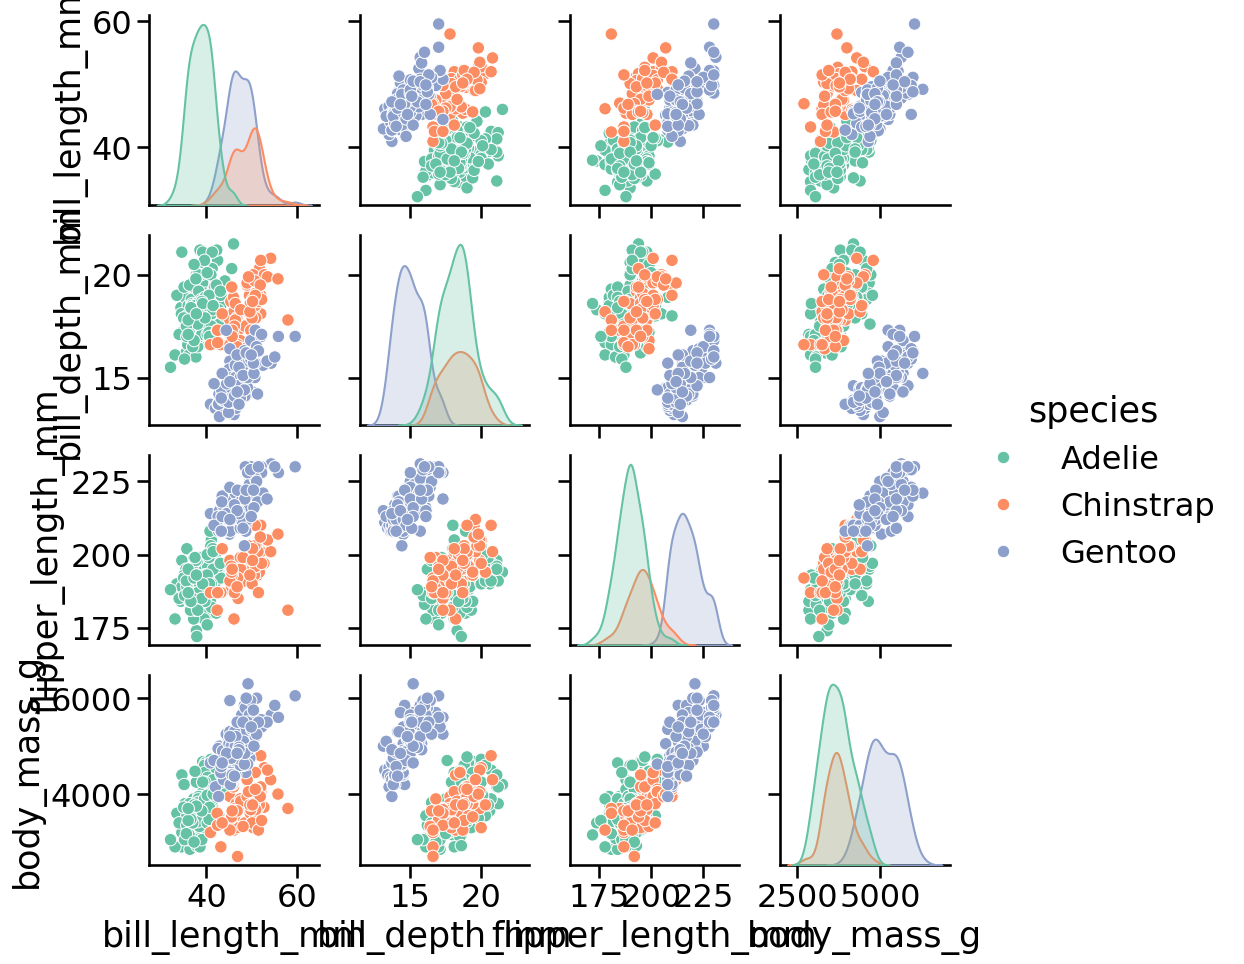

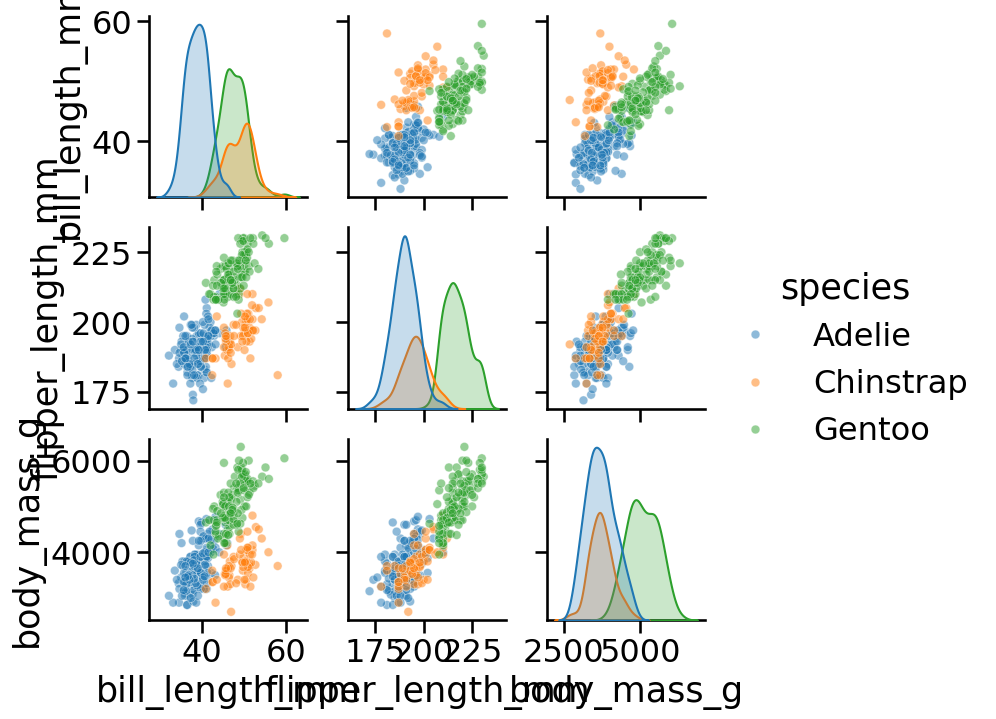

In [64]:
df = sns.load_dataset('penguins').dropna()

# Basic pairplot
sns.pairplot(df, hue='species', palette='Set2')
plt.show()

# Customized: KDE on diagonal, regression off diagonal
sns.pairplot(
    df, hue='species',
    diag_kind='kde',        # 'auto' | 'hist' | 'kde' | None
    plot_kws={'alpha': 0.5, 's': 40},  # scatter point size & transparency
    vars=['bill_length_mm', 'flipper_length_mm', 'body_mass_g']
)
plt.show()

c:\Learning_ML\venv\lib\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


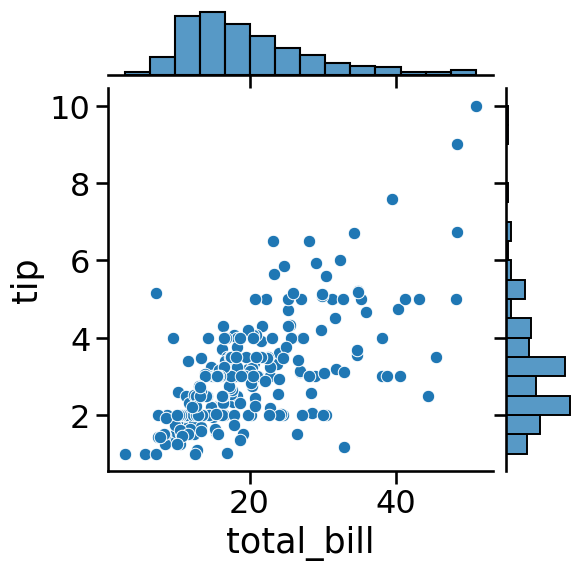

c:\Learning_ML\venv\lib\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
c:\Learning_ML\venv\lib\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
c:\Learning_ML\venv\lib\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
c:\Learning_ML\venv\lib\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


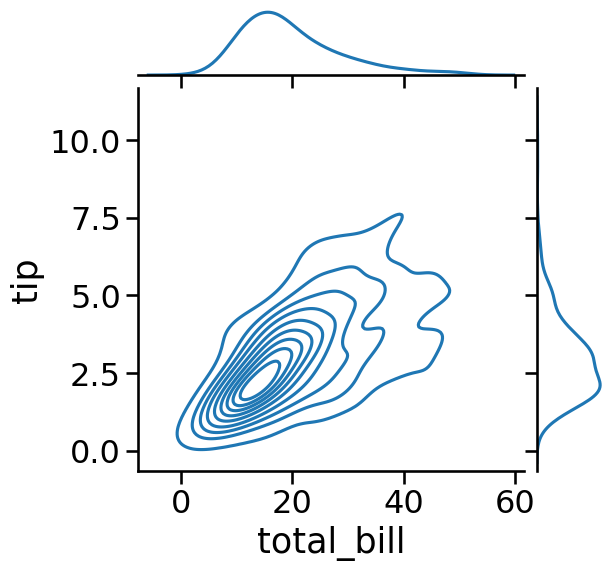

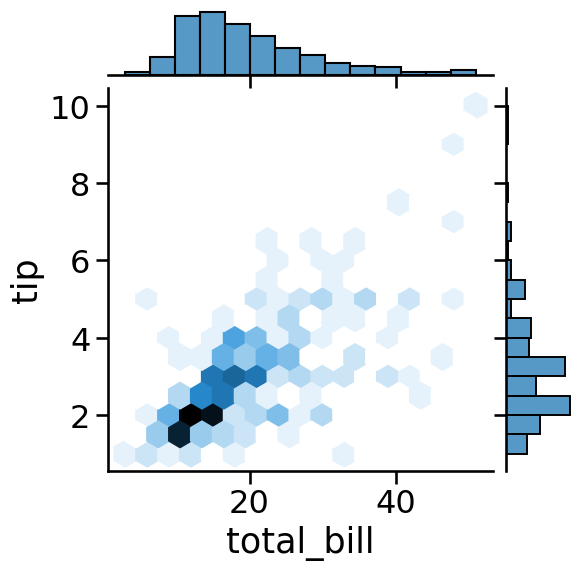

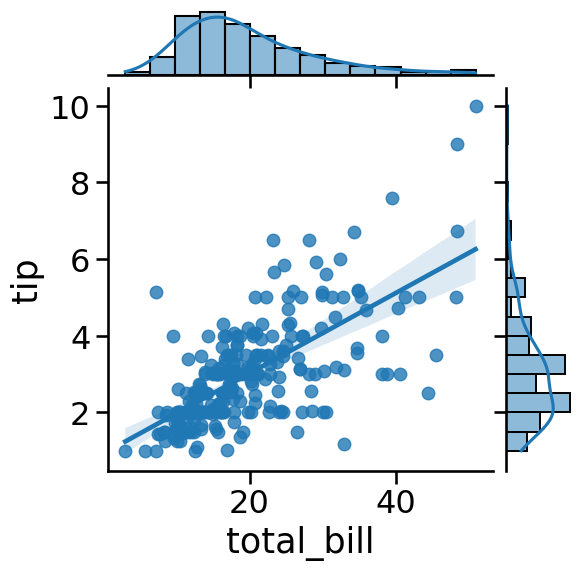

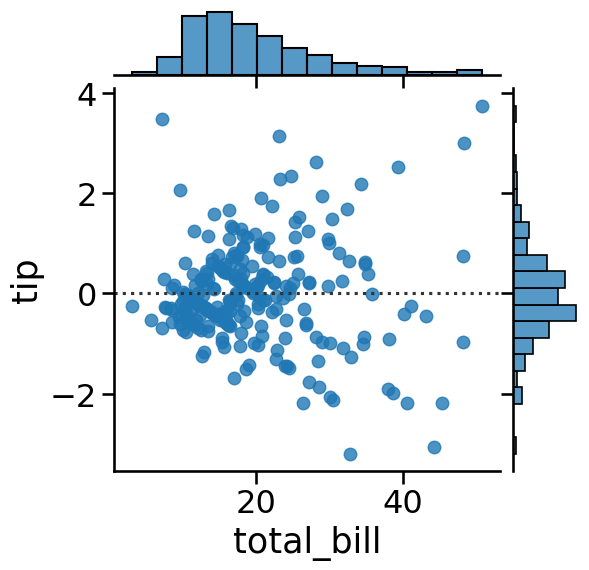

In [57]:
df = sns.load_dataset('tips')

# Scatter + marginal histograms
sns.jointplot(data=df, x='total_bill', y='tip',
              kind='scatter', height=6)
plt.show()

# Different kinds
sns.jointplot(data=df, x='total_bill', y='tip', kind='kde')
sns.jointplot(data=df, x='total_bill', y='tip', kind='hex')
sns.jointplot(data=df, x='total_bill', y='tip', kind='reg')
sns.jointplot(data=df, x='total_bill', y='tip', kind='resid')
plt.show()

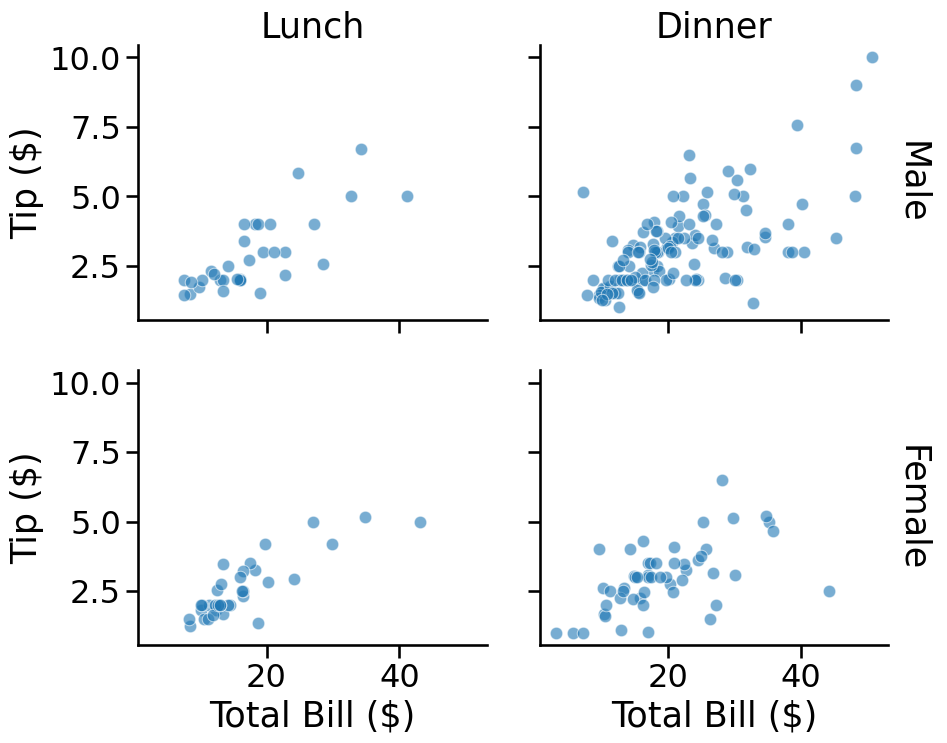

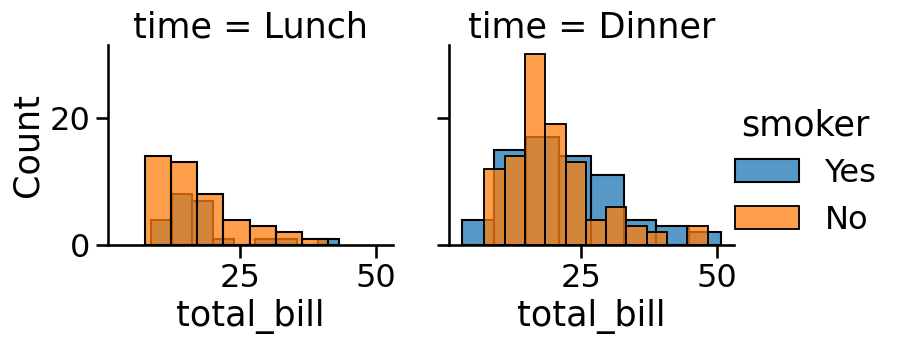

In [58]:
df = sns.load_dataset('tips')

# Define grid, then map a plot function
g = sns.FacetGrid(df, col='time', row='sex', height=4, aspect=1.2, margin_titles=True)

g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.6)
g.add_legend()
g.set_axis_labels('Total Bill ($)', 'Tip ($)')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
plt.show()

# Map with hue
g = sns.FacetGrid(df, col='time', hue='smoker', height=4)
g.map(sns.histplot, 'total_bill')
g.add_legend()
plt.show()

In [59]:
# Full theme setup (recommended)
sns.set_theme(
    style='darkgrid',   # 'darkgrid' | 'whitegrid' | 'dark' | 'white' | 'ticks'
    palette='Set2',
    font='sans-serif',
    font_scale=1.2       # scale all font sizes
)

# Change only style
sns.set_style('whitegrid')

# Axis-level override
sns.despine()           # remove top and right spines
sns.despine(left=True) # remove left spine too

# Reset to matplotlib defaults
sns.reset_defaults()

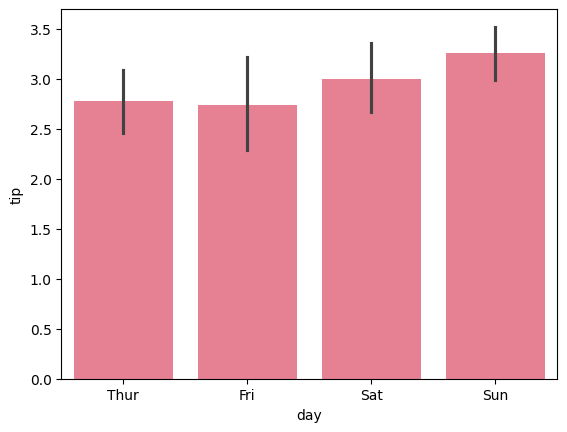

In [60]:
# View a palette (shows swatch in Jupyter)
sns.color_palette('Set2')

# Qualitative (categorical)
'Set1', 'Set2', 'Set3'
'tab10', 'tab20'
'pastel', 'muted', 'bright', 'deep', 'husl'

# Sequential (low → high)
'Blues', 'Greens', 'Oranges', 'viridis', 'plasma'

# Diverging (negative ↔ positive)
'coolwarm', 'RdBu', 'PiYG', 'BrBG'

# Custom palette from list
pal = sns.color_palette(['#e74c3c', '#3498db', '#2ecc71'])

# Apply as context manager
with sns.color_palette('husl', 8):
    sns.barplot(data=df, x='day', y='tip')
plt.show()

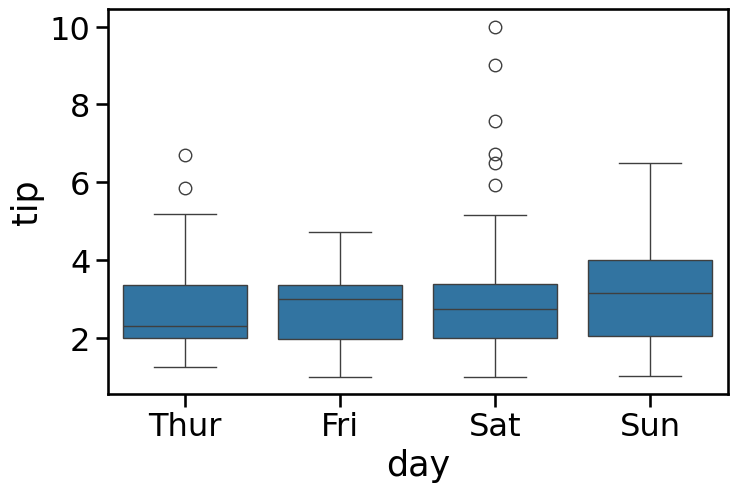

In [61]:
# Contexts scale lines, labels, and markers
sns.set_context('paper')     # smallest — for publications
sns.set_context('notebook')  # default
sns.set_context('talk')      # larger — for presentations
sns.set_context('poster')    # largest — for posters

# Fine-tune font scale within a context
sns.set_context('talk', font_scale=1.4)

fig, ax = plt.subplots(figsize=(8, 5))
df = sns.load_dataset('tips')
sns.boxplot(data=df, x='day', y='tip', ax=ax)
plt.show()